# Reto 1 — EDA Formal

Este notebook realiza análisis exploratorio formal orientado a diseñar la arquitectura analítica del reto 1. No es un reporte ejecutivo final — es una base técnica auditada para tres capas del sistema:

1. **Capa semántica**: soporte de consultas determinísticas del bot.
2. **Motor de insights automáticos**: detectores con reglas transparentes y defendibles.
3. **Evidencia de límites**: riesgos metodológicos explícitos antes del diseño funcional.

**Principios de diseño:**

- No conectar un LLM directamente al dataset crudo.
- Priorizar semántica explícita y ejecución determinística sobre generación libre.
- Separar los tipos de análisis: consulta, comparación, tendencia, insight, hipótesis.
- Tratar explicaciones de causalidad como hipótesis, nunca como hallazgo confirmado.
- Definir peer groups comparables antes de cualquier benchmarking.
- Diseñar detectores auditables (anomalías, deterioro persistente, desviación vs. peers).

In [1]:
# 0) Setup y contexto
from __future__ import annotations

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start] + list(start.parents):
        if (p / 'data' / 'processed').exists() and (p / 'src').exists():
            return p
    raise FileNotFoundError('No se pudo inferir project root desde el path actual.')

ROOT = find_project_root()
PROCESSED = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
DOCS = ROOT / 'docs'

metrics_long = pd.read_parquet(PROCESSED / 'metrics_long.parquet')
orders_long = pd.read_parquet(PROCESSED / 'orders_long.parquet')
zone_master = pd.read_parquet(PROCESSED / 'zone_master.parquet')

print('ROOT:', ROOT)
print('metrics_long:', metrics_long.shape)
print('orders_long :', orders_long.shape)
print('zone_master :', zone_master.shape)

ROOT: /home/thechieft/projects/IAeng
metrics_long: (104490, 14)
orders_long : (11178, 11)
zone_master : (1244, 13)


## 1) Validación de inputs

**Qué se hace:** Verificación de estructura, tipos de datos, grano lógico y consistencia de llaves antes de cualquier análisis.

**Por qué es importante:** Antes de calcular métricas, tendencias o comparaciones, se requiere garantizar que las tablas tienen la estructura esperada. Si el grano no es único, cualquier agregación posterior puede estar duplicada sin que sea obvio en el resultado final.

**Qué es "grano":** El grano es la combinación de columnas que identifica de manera única una fila en la tabla. Para `metrics_long`, el grano esperado es `(COUNTRY, CITY, ZONE, METRIC, WEEK_OFFSET)`. Cada combinación debe aparecer exactamente una vez. Si aparece más de una vez, significa que hay datos duplicados que contaminarían promedios, sumas y rankings.

**Riesgos que evita esta validación:**
- Detección temprana de duplicados que inflarían métricas de bot o alertas.
- Confirmación de que la transformación wide→long preservó la matemática correctamente.
- Garantía de que llaves categóricas son consistentes antes de cualquier join posterior.

In [2]:
def basic_profile(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        'table': [name],
        'rows': [df.shape[0]],
        'cols': [df.shape[1]],
        'null_cells': [int(df.isna().sum().sum())],
        'dup_exact_rows': [int(df.duplicated().sum())]
    })

summary = pd.concat([
    basic_profile(metrics_long, 'metrics_long'),
    basic_profile(orders_long, 'orders_long'),
    basic_profile(zone_master, 'zone_master')
], ignore_index=True)
summary

,table,rows,cols,null_cells,dup_exact_rows
0,metrics_long,104490,14,627,0
1,orders_long,11178,11,2104,0
2,zone_master,1244,13,1056,0


In [3]:
print('metrics_long dtypes')
display(metrics_long.dtypes.to_frame('dtype').T)
print('orders_long dtypes')
display(orders_long.dtypes.to_frame('dtype').T)
print('zone_master dtypes')
display(zone_master.dtypes.to_frame('dtype').T)

metrics_long dtypes


,COUNTRY,CITY,ZONE,ZONE_TYPE,ZONE_PRIORITIZATION,METRIC,metric_group,WEEK_OFFSET,week_offset_num,VALUE,SOURCE_TABLE,is_current_week,has_missing_history,_SOURCE_ROW_NUMBER
dtype,str,str,str,str,str,str,str,str,int64,float64,str,bool,bool,int64


orders_long dtypes


,COUNTRY,CITY,ZONE,METRIC,WEEK_OFFSET,week_offset_num,VALUE,SOURCE_TABLE,is_current_week,has_missing_history,_SOURCE_ROW_NUMBER
dtype,str,str,str,str,str,int64,float64,str,bool,bool,int64


zone_master dtypes


,COUNTRY,CITY,ZONE,METRIC_COUNT,ZONE_TYPE_NUNIQUE,ZONE_PRIORITIZATION_NUNIQUE,ZONE_TYPE,ZONE_PRIORITIZATION,IN_METRICS,IN_ORDERS,ZONE_TYPE_CONFLICT,ZONE_PRIORITIZATION_CONFLICT,COVERAGE_CLASS
dtype,str,str,str,int64,float64,float64,str,str,bool,bool,bool,bool,str


In [4]:
# Confirmación de grano esperado
metrics_grain = ['COUNTRY', 'CITY', 'ZONE', 'METRIC', 'WEEK_OFFSET']
orders_grain = ['COUNTRY', 'CITY', 'ZONE', 'METRIC', 'WEEK_OFFSET']

metrics_grain_dups = int(metrics_long.duplicated(subset=metrics_grain).sum())
orders_grain_dups = int(orders_long.duplicated(subset=orders_grain).sum())

pd.DataFrame({
    'table': ['metrics_long', 'orders_long'],
    'grain_duplicates': [metrics_grain_dups, orders_grain_dups],
    'is_grain_unique': [metrics_grain_dups == 0, orders_grain_dups == 0]
})

,table,grain_duplicates,is_grain_unique
0,metrics_long,0,True
1,orders_long,0,True


### 1.4 Auditoría de variables categóricas

**Qué se hace:** Revisión sistemática de las columnas categóricas clave para detectar inconsistencias de formato, casing o espaciado que puedan generar duplicados invisibles en joins y agrupaciones.

**Por qué importa:** Si `"Lima"` y `"LIMA"` coexisten como valores distintos en la columna CITY, cualquier `groupby` o join las trataría como dos entidades diferentes. Esto silenciosamente rompería peer groups, rankings y comparaciones sin generar ningún error explícito.

**Columnas auditadas:** `COUNTRY`, `CITY`, `ZONE`, `ZONE_TYPE`, `ZONE_PRIORITIZATION`, `METRIC`

**Criterios de revisión:**
1. Valores únicos por columna (cardinalidad).
2. Detección de espacios al inicio o final del string.
3. Colisiones por casing: valores idénticos al normalizar a STRIP + UPPER.
4. Ejemplos concretos si se encuentran inconsistencias.
5. Propuesta de clave canónica para uso analítico interno.

**Nota importante:** Esta auditoría no modifica los datos. Si se propone una normalización, se documenta qué haría y qué riesgo evita.

In [5]:
def audit_categorical(df: pd.DataFrame, col: str, table_name: str) -> dict:
    """Audita una columna categórica: cardinalidad, espacios, colisiones por casing."""
    series = df[col].dropna().astype(str)
    n_unique = series.nunique()

    # Filas con espacios al inicio o final
    has_leading_trailing = int(series.apply(lambda x: x != x.strip()).sum())

    # Colisiones por casing (valores idénticos al normalizar a STRIP + UPPER)
    series_norm = series.str.strip().str.upper()
    n_unique_normalized = series_norm.nunique()
    casing_collisions = n_unique - n_unique_normalized

    # Ejemplos concretos de colisiones
    collision_examples = []
    if casing_collisions > 0:
        for key, group in series.groupby(series_norm):
            variants = sorted(group.unique())
            if len(variants) > 1:
                collision_examples.append(variants)
                if len(collision_examples) >= 3:
                    break

    status = 'OK' if (casing_collisions == 0 and has_leading_trailing == 0) else 'REVISAR'
    return {
        'table': table_name,
        'column': col,
        'n_unique': n_unique,
        'n_unique_strip_upper': n_unique_normalized,
        'casing_collisions': casing_collisions,
        'rows_with_spaces': has_leading_trailing,
        'status': status,
        'collision_examples': collision_examples,
    }

cols_metrics = ['COUNTRY', 'CITY', 'ZONE', 'ZONE_TYPE', 'ZONE_PRIORITIZATION', 'METRIC']
cols_orders  = ['COUNTRY', 'CITY', 'ZONE', 'METRIC']

audit_results = []
for col in cols_metrics:
    audit_results.append(audit_categorical(metrics_long, col, 'metrics_long'))
for col in cols_orders:
    audit_results.append(audit_categorical(orders_long, col, 'orders_long'))

audit_df = pd.DataFrame(audit_results)
display(
    audit_df[['table', 'column', 'n_unique', 'n_unique_strip_upper',
              'casing_collisions', 'rows_with_spaces', 'status']]
)

# Detalle de inconsistencias si existen
print("\n--- Detalle de colisiones por casing (si existen) ---")
any_issue = False
for r in audit_results:
    if r['status'] != 'OK':
        any_issue = True
        print(f"\n[{r['table']}] {r['column']}: "
              f"{r['casing_collisions']} colisiones, {r['rows_with_spaces']} filas con espacios")
        for ex in r['collision_examples']:
            print(f"  Ejemplo: {ex}")
if not any_issue:
    print("Sin inconsistencias de casing ni espaciado en ninguna columna auditada.")

# Propuesta de clave canónica
print("\n--- Propuesta de clave canónica para uso analítico ---")
print("Regla defensiva sugerida: aplicar STRIP + UPPER en todas las columnas categóricas")
print("en el momento de join o groupby, independientemente del estado actual.")
ok_cols     = [r['column'] for r in audit_results if r['status'] == 'OK'     and r['table'] == 'metrics_long']
review_cols = [r['column'] for r in audit_results if r['status'] != 'OK'     and r['table'] == 'metrics_long']
print(f"  Columnas limpias (metrics_long): {ok_cols}")
print(f"  Columnas que requieren revisión (metrics_long): {review_cols if review_cols else 'Ninguna'}")

,table,column,n_unique,n_unique_strip_upper,casing_collisions,rows_with_spaces,status
0,metrics_long,COUNTRY,9,9,0,0,OK
1,metrics_long,CITY,270,270,0,0,OK
2,metrics_long,ZONE,964,963,1,0,REVISAR
3,metrics_long,ZONE_TYPE,2,2,0,0,OK
4,metrics_long,ZONE_PRIORITIZATION,3,3,0,0,OK
5,metrics_long,METRIC,13,13,0,0,OK
6,orders_long,COUNTRY,9,9,0,0,OK
7,orders_long,CITY,342,342,0,0,OK
8,orders_long,ZONE,1188,1187,1,0,REVISAR
9,orders_long,METRIC,1,1,0,0,OK



--- Detalle de colisiones por casing (si existen) ---

[metrics_long] ZONE: 1 colisiones, 0 filas con espacios
  Ejemplo: ['Centro', 'centro']

[orders_long] ZONE: 1 colisiones, 0 filas con espacios
  Ejemplo: ['Centro', 'centro']

--- Propuesta de clave canónica para uso analítico ---
Regla defensiva sugerida: aplicar STRIP + UPPER en todas las columnas categóricas
en el momento de join o groupby, independientemente del estado actual.
  Columnas limpias (metrics_long): ['COUNTRY', 'CITY', 'ZONE_TYPE', 'ZONE_PRIORITIZATION', 'METRIC']
  Columnas que requieren revisión (metrics_long): ['ZONE']


---
**Qué nos llevamos de esta sección**

- Grano verificado: `(COUNTRY, CITY, ZONE, METRIC, WEEK_OFFSET)` es único en ambas tablas long. Las consultas y agregaciones del bot no tienen riesgo de duplicación silenciosa.
- Tipos de datos correctos: columnas numéricas en `float64`, categóricas en `str`, flags booleanos consistentes.
- Auditoría categórica completada: ver subsección 1.4 para el estado de cada columna.
- Las tablas procesadas están listas para análisis — cualquier problema aquí hubiera invalidado todo lo siguiente.

## 2) Calidad de datos post-transformación

**Qué se hace:** Evaluación de valores faltantes, cobertura temporal, cobertura geográfica y consistencia entre tablas de métricas y órdenes.

**Por qué importa la cobertura:** El bot y el insight engine van a consultar datos por zona, métrica y semana. Si una zona no tiene datos en `L3W`, un ranking de "top zonas" que incluya esa semana será silenciosamente parcial — y potencialmente engañoso.

**Por qué importa el mismatch entre métricas y órdenes:** El bot necesita cruzar métricas operativas con datos de órdenes para preguntas del tipo "¿qué métricas covarían con el crecimiento de órdenes?". Si las zonas no son idénticas entre tablas, el join omite zonas sin avisar. Eso afecta directamente la calidad de hipótesis del insight engine y la comparabilidad entre segmentos.

**Qué se mide:**
- Missing values por columna (solo `VALUE` puede tener nulos — es el único campo no-estructural).
- Cobertura temporal: todos los offsets `L0W`–`L8W` deben estar presentes.
- Cobertura geográfica: países, ciudades, zonas por tabla.
- Grado de mismatch entre las zonas de métricas y órdenes.
- Porcentaje de series históricas con al menos un valor faltante en la ventana de 9 semanas.

In [6]:
missing_metrics = metrics_long.isna().sum().sort_values(ascending=False)
missing_orders = orders_long.isna().sum().sort_values(ascending=False)

display(missing_metrics.head(15).to_frame('missing_metrics'))
display(missing_orders.head(15).to_frame('missing_orders'))

,missing_metrics
VALUE,627
COUNTRY,0
CITY,0
ZONE,0
ZONE_TYPE,0
ZONE_PRIORITIZATION,0
METRIC,0
metric_group,0
WEEK_OFFSET,0
week_offset_num,0


,missing_orders
VALUE,2104
COUNTRY,0
CITY,0
ZONE,0
METRIC,0
WEEK_OFFSET,0
week_offset_num,0
SOURCE_TABLE,0
is_current_week,0
has_missing_history,0


In [7]:
# Cobertura temporal
temporal_cov = pd.DataFrame({
    'table': ['metrics_long', 'orders_long'],
    'min_week_offset_num': [metrics_long['week_offset_num'].min(), orders_long['week_offset_num'].min()],
    'max_week_offset_num': [metrics_long['week_offset_num'].max(), orders_long['week_offset_num'].max()],
    'n_offsets': [metrics_long['WEEK_OFFSET'].nunique(), orders_long['WEEK_OFFSET'].nunique()]
})
temporal_cov

,table,min_week_offset_num,max_week_offset_num,n_offsets
0,metrics_long,0,8,9
1,orders_long,0,8,9


In [8]:
# Cobertura por país / ciudad / zona
geo_cov = pd.DataFrame({
    'table': ['metrics_long', 'orders_long', 'zone_master'],
    'countries': [metrics_long['COUNTRY'].nunique(), orders_long['COUNTRY'].nunique(), zone_master['COUNTRY'].nunique()],
    'cities': [metrics_long['CITY'].nunique(), orders_long['CITY'].nunique(), zone_master['CITY'].nunique()],
    'zones': [metrics_long[['COUNTRY','CITY','ZONE']].drop_duplicates().shape[0], orders_long[['COUNTRY','CITY','ZONE']].drop_duplicates().shape[0], zone_master[['COUNTRY','CITY','ZONE']].drop_duplicates().shape[0]]
})
geo_cov

,table,countries,cities,zones
0,metrics_long,9,270,980
1,orders_long,9,342,1242
2,zone_master,9,342,1244


In [9]:
# Consistencia entre tablas
metrics_zones = set(metrics_long[['COUNTRY', 'CITY', 'ZONE']].drop_duplicates().itertuples(index=False, name=None))
orders_zones = set(orders_long[['COUNTRY', 'CITY', 'ZONE']].drop_duplicates().itertuples(index=False, name=None))
zm_zones = set(zone_master[['COUNTRY', 'CITY', 'ZONE']].drop_duplicates().itertuples(index=False, name=None))

consistency = pd.DataFrame({
    'check': [
        'zone_master == union(metrics, orders)',
        'metrics_only_zones',
        'orders_only_zones'
    ],
    'value': [
        zm_zones == (metrics_zones | orders_zones),
        len(metrics_zones - orders_zones),
        len(orders_zones - metrics_zones)
    ]
})
consistency

,check,value
0,"zone_master == union(metrics, orders)",True
1,metrics_only_zones,2
2,orders_only_zones,264


In [10]:
# Zonas con historia incompleta
metrics_incomplete = metrics_long.groupby(['COUNTRY','CITY','ZONE','METRIC'], dropna=False)['VALUE'].apply(lambda s: s.isna().any()).reset_index(name='has_missing_history')
orders_incomplete = orders_long.groupby(['COUNTRY','CITY','ZONE','METRIC'], dropna=False)['VALUE'].apply(lambda s: s.isna().any()).reset_index(name='has_missing_history')

pd.DataFrame({
    'table': ['metrics_long', 'orders_long'],
    'entity_histories': [metrics_incomplete.shape[0], orders_incomplete.shape[0]],
    'histories_with_missing': [int(metrics_incomplete['has_missing_history'].sum()), int(orders_incomplete['has_missing_history'].sum())],
    'pct_with_missing': [metrics_incomplete['has_missing_history'].mean(), orders_incomplete['has_missing_history'].mean()]
})

,table,entity_histories,histories_with_missing,pct_with_missing
0,metrics_long,11610,173,0.014901
1,orders_long,1242,310,0.249597


---
**Qué nos llevamos de esta sección**

- Solo la columna `VALUE` tiene nulos: 627 en métricas (0.6%), 2,104 en órdenes (18.8%). No hay nulos estructurales — la calidad de llaves es alta.
- Mismatch real: 264 zonas están en órdenes pero no en métricas. Cualquier análisis cruzado debe declarar explícitamente cómo trata estas zonas (exclusión, imputación, flag).
- 25% de series de órdenes tienen al menos un valor faltante en su historia de 9 semanas. Detectores de tendencia y rachas deben manejar este caso explícitamente.
- El `zone_master` es la fuente de verdad para cobertura: su diseño como unión intencional es correcto y ya está implementado.

## 3) Inventario semántico de métricas

**Qué se hace:** Organización de las métricas disponibles por naturaleza, orientación deseable y riesgo de interpretación.

**Por qué hace falta antes del bot:** Un chatbot que responde "¿cuál es la métrica más alta?" sin saber si alto es bueno o malo en esa métrica generaría respuestas incorrectas o peligrosas. El inventario semántico es el prerrequisito para que el bot pueda generar narrativa correcta, no solo números.

**Por qué algunas métricas no se interpretan igual:**
- `Gross Profit UE` puede ser negativo (pérdida por unidad económica) — su rango cruza cero y tiene outliers extremos. Requiere interpretación distinta a las métricas de ratio.
- `Restaurants Markdowns / GMV` mide descuentos como proporción: bajo es mejor (menos descuento necesario). La dirección deseable es inversa a las métricas de tasa.
- `Lead Penetration` tiene outliers extremos (máx 393.9 en escala de ratio 0-1) que distorsionan rankings y promedios si no se tratan.
- Métricas tipo CVR y adoption tienen escala 0–1 y se leen como tasas. `Gross Profit UE` tiene escala libre en unidades monetarias.

**Método:** Para cada métrica se calculan estadísticas descriptivas, se infiere naturaleza (ratio/tasa vs. absoluta/monetaria) y orientación deseable como hipótesis de trabajo. Ninguna de estas etiquetas es definitiva — requieren validación con el área de negocio.

In [11]:
metric_stats = (
    metrics_long.groupby('METRIC', dropna=False)['VALUE']
    .agg(
        rows='count',
        missing=lambda s: s.isna().sum(),
        min='min',
        p25=lambda s: s.quantile(0.25),
        median='median',
        p75=lambda s: s.quantile(0.75),
        max='max',
        std='std'
    )
    .reset_index()
    .sort_values('rows', ascending=False)
)
metric_stats.head(20)

,METRIC,rows,missing,min,p25,median,p75,max,std
5,Non-Pro PTC > OP,8788,5,0.000000,0.659552,0.716683,0.767505,1.000000,0.147440
1,% Restaurants Sessions With Optimal Assortment,8691,3,0.000000,0.014140,0.731967,0.901634,1.000000,0.390173
7,Pro Adoption (Last Week Status),8636,13,0.000000,0.224013,0.283835,0.366648,1.000000,0.119221
9,Restaurants SS > ATC CVR,8611,11,0.000000,0.454681,0.531389,0.580348,0.866667,0.102828
10,Restaurants SST > SS CVR,8611,11,0.116364,0.862690,0.895864,0.919050,1.000000,0.072834
2,Gross Profit UE,8514,117,-229.193676,-0.795288,0.792321,2.221495,12.842822,7.227122
11,Retail SST > SS CVR,8489,25,0.000000,0.851988,0.891836,0.920008,1.000000,0.103059
0,% PRO Users Who Breakeven,8367,3,0.000000,0.202624,0.312903,0.434262,1.000000,0.174887
3,Lead Penetration,8326,53,0.001161,0.070524,0.144012,0.264482,393.900000,14.006190
6,Perfect Orders,8268,138,0.136713,0.838378,0.883352,0.906636,1.000000,0.098980


In [12]:
def infer_metric_nature(metric_name: str) -> str:
    m = metric_name.lower()
    if 'cvr' in m or 'adoption' in m or 'penetration' in m or 'perfect' in m or 'breakeven' in m:
        return 'ratio_or_rate'
    if 'profit' in m or 'orders' in m:
        return 'absolute_or_currency'
    return 'mixed_or_unknown'

def infer_desirability(metric_name: str) -> str:
    m = metric_name.lower()
    if 'markdowns' in m:
        return 'bajo_mejor (hipótesis)'
    if 'profit' in m or 'orders' in m or 'perfect' in m or 'cvr' in m or 'adoption' in m or 'penetration' in m or 'breakeven' in m:
        return 'alto_mejor (hipótesis)'
    return 'depende / por_validar'

semantic_inventory = metric_stats.copy()
semantic_inventory['metric_nature_apparent'] = semantic_inventory['METRIC'].map(infer_metric_nature)
semantic_inventory['desirable_direction_hypothesis'] = semantic_inventory['METRIC'].map(infer_desirability)
semantic_inventory['interpretation_risk'] = np.where(semantic_inventory['max'].abs() > 5, 'alto', 'medio')
semantic_inventory[['METRIC','rows','missing','min','median','max','metric_nature_apparent','desirable_direction_hypothesis','interpretation_risk']].head(30)

,METRIC,rows,missing,min,median,max,metric_nature_apparent,desirable_direction_hypothesis,interpretation_risk
5,Non-Pro PTC > OP,8788,5,0.000000,0.716683,1.000000,mixed_or_unknown,depende / por_validar,medio
1,% Restaurants Sessions With Optimal Assortment,8691,3,0.000000,0.731967,1.000000,mixed_or_unknown,depende / por_validar,medio
7,Pro Adoption (Last Week Status),8636,13,0.000000,0.283835,1.000000,ratio_or_rate,alto_mejor (hipótesis),medio
9,Restaurants SS > ATC CVR,8611,11,0.000000,0.531389,0.866667,ratio_or_rate,alto_mejor (hipótesis),medio
10,Restaurants SST > SS CVR,8611,11,0.116364,0.895864,1.000000,ratio_or_rate,alto_mejor (hipótesis),medio
2,Gross Profit UE,8514,117,-229.193676,0.792321,12.842822,absolute_or_currency,alto_mejor (hipótesis),alto
11,Retail SST > SS CVR,8489,25,0.000000,0.891836,1.000000,ratio_or_rate,alto_mejor (hipótesis),medio
0,% PRO Users Who Breakeven,8367,3,0.000000,0.312903,1.000000,ratio_or_rate,alto_mejor (hipótesis),medio
3,Lead Penetration,8326,53,0.001161,0.144012,393.900000,ratio_or_rate,alto_mejor (hipótesis),alto
6,Perfect Orders,8268,138,0.136713,0.883352,1.000000,ratio_or_rate,alto_mejor (hipótesis),medio


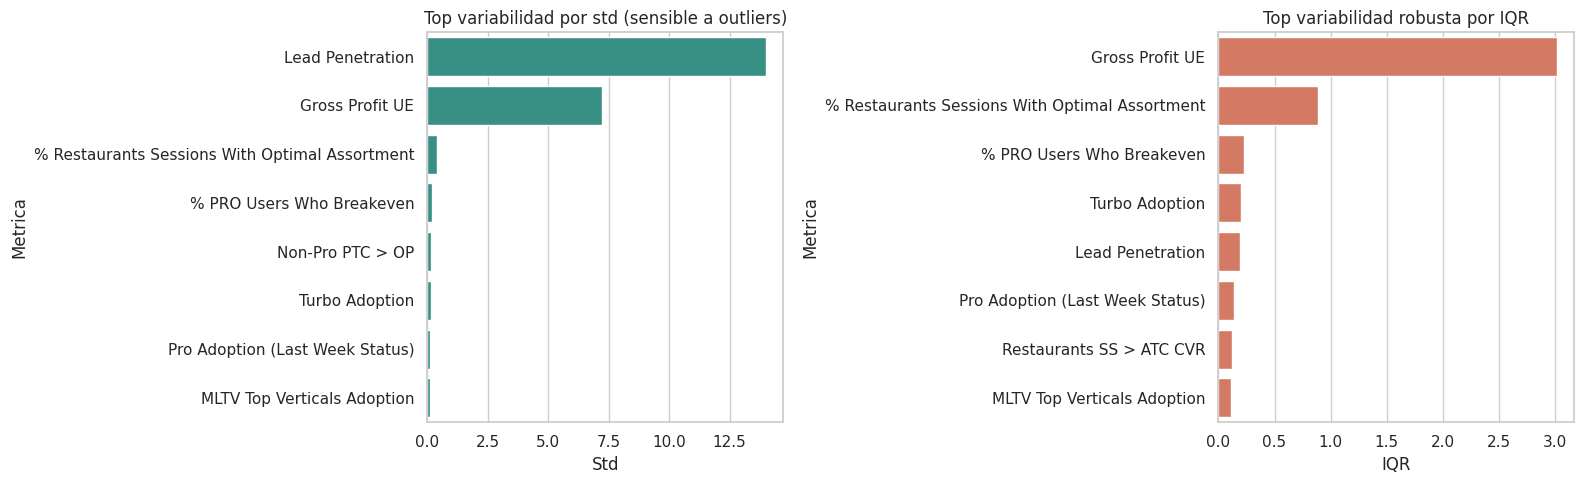

In [13]:
# Comparativa de dispersion robusta para evitar lectura sesgada por outliers extremos.
dispersion = semantic_inventory[['METRIC', 'std', 'p25', 'p75']].copy()
dispersion['iqr'] = dispersion['p75'] - dispersion['p25']
dispersion['robust_dispersion_score'] = dispersion['iqr']

top_std = dispersion.sort_values('std', ascending=False).head(8)
top_iqr = dispersion.sort_values('robust_dispersion_score', ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=top_std, x='std', y='METRIC', color='#2a9d8f', ax=axes[0])
axes[0].set_title('Top variabilidad por std (sensible a outliers)')
axes[0].set_xlabel('Std')
axes[0].set_ylabel('Metrica')

sns.barplot(data=top_iqr, x='robust_dispersion_score', y='METRIC', color='#e76f51', ax=axes[1])
axes[1].set_title('Top variabilidad robusta por IQR')
axes[1].set_xlabel('IQR')
axes[1].set_ylabel('Metrica')

plt.tight_layout()
plt.show()

**Lectura metodológica: IQR vs. Desviación Estándar (STD)**

Los dos gráficos anteriores miden variabilidad con métodos distintos. La diferencia importa para diseñar las reglas del insight engine.

**STD (desviación estándar):**  
Mide la dispersión promedio de todos los valores respecto a la media. Es sensible a outliers: un solo valor extremo puede inflar enormemente la STD de toda la distribución. Si `Lead Penetration` tiene un outlier de 393 en una escala 0–1, su STD refleja ese outlier más que la variabilidad real de las zonas típicas.

**IQR (rango intercuartil = P75 − P25):**  
Mide la dispersión del 50% central de los datos. Es robusto frente a outliers: valores extremos no entran en el cálculo porque están por fuera del P25–P75. Captura la variabilidad que enfrentarán la mayoría de las zonas.

**Resultado en este dataset:**  
`Gross Profit UE` y `Lead Penetration` lideran la STD, pero su posición cambia al usar IQR — lo que confirma que su alta STD es principalmente ruido de outliers, no dispersión estructural del grupo central. Las métricas tipo CVR tienen STD baja pero IQR consistente, indicando variabilidad genuina en el rango central.

**Implicación para el insight engine:**  
Umbrales de alerta basados en STD se dispararán frecuentemente por outliers aislados — generando falsas alarmas. Preferir IQR o robust z-score (MAD) para definir umbrales de anomalía. Reservar STD solo para métricas que se sabe tienen distribución aproximadamente normal y sin outliers extremos.

---
**Qué nos llevamos de esta sección**

- 13 métricas únicas en la base. Todas tienen naturaleza aparente inferida, pero la dirección deseable requiere validación de negocio antes de producción.
- `Lead Penetration` y `Gross Profit UE` tienen outliers extremos que distorsionan métricas de dispersión. Requieren tratamiento diferenciado en el insight engine.
- IQR es más adecuado que STD como base para umbrales de alerta en la mayoría de métricas de este dataset.
- Sin catálogo formal de métricas, el bot no puede generar narrativa correcta sobre "mejor" o "peor".

## 4) Estructura geográfica y comparabilidad (peer groups)

**Qué se hace:** Evaluación de la distribución de zonas por país y ciudad, definición de peer groups para benchmarking y análisis de robustez de esos grupos.

**Por qué se definen así los peer groups:**  
Un peer group agrupa zonas que son comparables entre sí. La combinación `(COUNTRY, ZONE_TYPE, ZONE_PRIORITIZATION)` captura tres dimensiones de comparabilidad natural: el mercado (país), el perfil socioeconómico de la zona (Wealthy/Non Wealthy) y la prioridad operativa (High Priority/Prioritized/Not Prioritized). Comparar una zona Wealthy de alta prioridad en Brasil contra una Non Wealthy no priorizada en UY sería metodológicamente incorrecto — no son pares naturales.

**Qué significa un peer group débil:**  
Un peer group con menos de 10 zonas es estadísticamente frágil. Si se calcula la mediana del grupo con 2–3 zonas, ese valor no es representativo — y la "desviación vs. peer median" de una zona individual puede estar dominada por sus propios valores.

**Riesgo de benchmark con peers pobres:**  
Si el insight engine alerta "esta zona está 20% por debajo del peer median" pero ese peer median viene de un grupo de 3 zonas, la alerta puede ser un falso positivo por falta de representatividad. Peor aún, si una de las 3 zonas del peer tiene un outlier, la mediana se desplaza y la zona auditada puede parecer problemática cuando no lo es.

In [14]:
zones_by_country = zone_master.groupby('COUNTRY', dropna=False).size().reset_index(name='zones').sort_values('zones', ascending=False)
zones_by_city = zone_master.groupby(['COUNTRY','CITY'], dropna=False).size().reset_index(name='zones').sort_values('zones', ascending=False)

display(zones_by_country.head(20))
display(zones_by_city.head(20))

,COUNTRY,zones
1,BR,417
6,MX,331
3,CO,135
0,AR,98
7,PE,92
5,EC,75
2,CL,66
4,CR,21
8,UY,9


,COUNTRY,CITY,zones
2,AR,Buenos Aires,39
340,PE,Lima,38
105,BR,Rio De Janeiro,35
89,BR,Other,34
60,BR,Grande São Paulo,32
206,EC,Quito,29
145,CL,Santiago De Chile,27
201,EC,Guayaquil,26
155,CO,Bogota,17
222,MX,Ciudad De Mexico,17


In [15]:
peer_dims = ['COUNTRY', 'ZONE_TYPE', 'ZONE_PRIORITIZATION']
peer_groups = zone_master.groupby(peer_dims, dropna=False).agg(
    zones=('ZONE', 'count'),
    zones_in_metrics=('IN_METRICS', 'sum'),
    zones_in_orders=('IN_ORDERS', 'sum')
).reset_index()

peer_groups['is_weak_group'] = peer_groups['zones'] < 10
peer_groups['metrics_coverage_ratio'] = peer_groups['zones_in_metrics'] / peer_groups['zones']
peer_groups['orders_coverage_ratio'] = peer_groups['zones_in_orders'] / peer_groups['zones']

peer_summary = pd.DataFrame({
    'total_peer_groups': [peer_groups.shape[0]],
    'weak_groups_lt_10_zones': [int(peer_groups['is_weak_group'].sum())],
    'pct_weak_groups': [peer_groups['is_weak_group'].mean()],
    'median_group_size': [peer_groups['zones'].median()]
})

display(peer_summary)
display(
    peer_groups.sort_values(['is_weak_group', 'zones'], ascending=[False, True]).head(25)
    [['COUNTRY','ZONE_TYPE','ZONE_PRIORITIZATION','zones','metrics_coverage_ratio','orders_coverage_ratio','is_weak_group']]
)

,total_peer_groups,weak_groups_lt_10_zones,pct_weak_groups,median_group_size
0,52,25,0.480769,11.5


,COUNTRY,ZONE_TYPE,ZONE_PRIORITIZATION,zones,metrics_coverage_ratio,orders_coverage_ratio,is_weak_group
4,AR,Wealthy,Not Prioritized,1,1.0,1.0,True
45,PE,Wealthy,High Priority,1,1.0,1.0,True
49,UY,Non Wealthy,Not Prioritized,1,1.0,1.0,True
3,AR,Wealthy,High Priority,2,1.0,1.0,True
6,AR,NaN,NaN,2,0.0,1.0,True
17,CL,Wealthy,High Priority,2,1.0,1.0,True
18,CL,Wealthy,Not Prioritized,2,1.0,1.0,True
25,CO,Wealthy,Not Prioritized,2,1.0,1.0,True
39,MX,Wealthy,Not Prioritized,2,1.0,1.0,True
48,UY,Non Wealthy,High Priority,2,1.0,1.0,True


In [16]:
# Cobertura de metricas dentro de peer groups
metrics_entity = metrics_long[['COUNTRY', 'CITY', 'ZONE', 'ZONE_TYPE', 'ZONE_PRIORITIZATION', 'METRIC']].drop_duplicates()
peer_metric_cov = (
    metrics_entity
    .groupby(peer_dims + ['METRIC'], dropna=False)
    .size()
    .reset_index(name='zones_with_metric')
)

peer_size = zone_master.groupby(peer_dims, dropna=False).size().reset_index(name='peer_size')
peer_metric_cov = peer_metric_cov.merge(peer_size, on=peer_dims, how='left')
peer_metric_cov['coverage_ratio'] = peer_metric_cov['zones_with_metric'] / peer_metric_cov['peer_size']

cov_summary = pd.DataFrame({
    'peer_metric_combinations': [peer_metric_cov.shape[0]],
    'combos_below_70pct_cov': [int((peer_metric_cov['coverage_ratio'] < 0.70).sum())],
    'pct_below_70pct_cov': [(peer_metric_cov['coverage_ratio'] < 0.70).mean()],
    'median_cov_ratio': [peer_metric_cov['coverage_ratio'].median()]
})

low_cov = peer_metric_cov.sort_values('coverage_ratio', ascending=True).head(25)

display(cov_summary)
display(low_cov[['COUNTRY', 'ZONE_TYPE', 'ZONE_PRIORITIZATION', 'METRIC', 'zones_with_metric', 'peer_size', 'coverage_ratio']])

,peer_metric_combinations,combos_below_70pct_cov,pct_below_70pct_cov,median_cov_ratio
0,539,19,0.03525,1.0


,COUNTRY,ZONE_TYPE,ZONE_PRIORITIZATION,METRIC,zones_with_metric,peer_size,coverage_ratio
388,MX,Non Wealthy,Not Prioritized,Turbo Adoption,1,94,0.010638
173,CL,Non Wealthy,Not Prioritized,Turbo Adoption,1,24,0.041667
465,PE,Non Wealthy,Not Prioritized,Turbo Adoption,3,28,0.107143
401,MX,Non Wealthy,Prioritized,Turbo Adoption,30,119,0.252101
186,CL,Non Wealthy,Prioritized,Turbo Adoption,5,16,0.312500
250,CO,Non Wealthy,Not Prioritized,Turbo Adoption,16,42,0.380952
439,MX,Wealthy,Prioritized,Turbo Adoption,23,57,0.403509
538,UY,Non Wealthy,Prioritized,Turbo Adoption,2,4,0.500000
289,CO,Wealthy,Not Prioritized,Turbo Adoption,1,2,0.500000
517,UY,Non Wealthy,High Priority,Turbo Adoption,1,2,0.500000


---
**Qué nos llevamos de esta sección**

- 48% de peer groups tienen menos de 10 zonas — son estadísticamente débiles para benchmarking. Cualquier alerta generada sobre esos grupos debe marcarse como "low-confidence".
- La cobertura de métricas dentro de peer groups es alta (mediana 100%), con excepción de `Turbo Adoption`, que tiene cobertura muy baja en varios grupos.
- `Turbo Adoption` no debe incluirse en comparaciones peer hasta tener cobertura mínima — podría sesgar benchmarks negativamente para zonas que sí la adoptaron.
- Se recomienda definir un umbral mínimo de peer size (sugerido: ≥10 zonas) antes de activar comparaciones automáticas en el motor de insights.

## 5) Exploración temporal operativa

**Qué se hace:** Análisis de tendencias, volatilidad y cambios semana a semana (WoW) en métricas y órdenes.

**Por qué no se hace forecasting complejo:**  
Con 9 semanas de historia, cualquier modelo de series de tiempo (ARIMA, Prophet, etc.) tendría parámetros no identificables de forma confiable. 9 puntos no son suficientes para distinguir entre tendencia secular, estacionalidad y ruido. Usar modelos complejos con tan pocos datos introduce más incertidumbre de la que resuelve y da una falsa sensación de precisión.

**Por qué el foco está en WoW, estabilidad y drift simple:**
- **WoW (Week-over-Week):** el cambio de una semana a la siguiente es el indicador más interpretable para operaciones. No requiere suposiciones de distribución ni parámetros entrenados.
- **Estabilidad:** identificar si una zona tiene comportamiento estable vs. errático en las últimas semanas es accionable sin forecasting.
- **Drift simple:** detectar si hay una dirección sostenida (subida o bajada progresiva) es útil con 9 semanas. No se puede afirmar si la tendencia continuará, pero sí documentar que ya ocurrió.

**Método:** Se calculan agregados por offset temporal, delta WoW absoluto y porcentual, y volatilidad por métrica (std de la serie por entidad zona+métrica).

In [17]:
orders_agg = orders_long.groupby('week_offset_num', dropna=False)['VALUE'].sum().reset_index().sort_values('week_offset_num', ascending=False)
orders_agg['wow_delta_abs'] = orders_agg['VALUE'].diff(-1)
orders_agg['wow_delta_pct'] = orders_agg['VALUE'].pct_change(-1)
orders_agg

,week_offset_num,VALUE,wow_delta_abs,wow_delta_pct
8,8,5134430.0,-20862.0,-0.004047
7,7,5155292.0,-101274.0,-0.019266
6,6,5256566.0,49954.0,0.009594
5,5,5206612.0,-5860.0,-0.001124
4,4,5212472.0,6387.0,0.001227
3,3,5206085.0,-70992.0,-0.013453
2,2,5277077.0,120841.0,0.023436
1,1,5156236.0,-66977.0,-0.012823
0,0,5223213.0,NaN,NaN


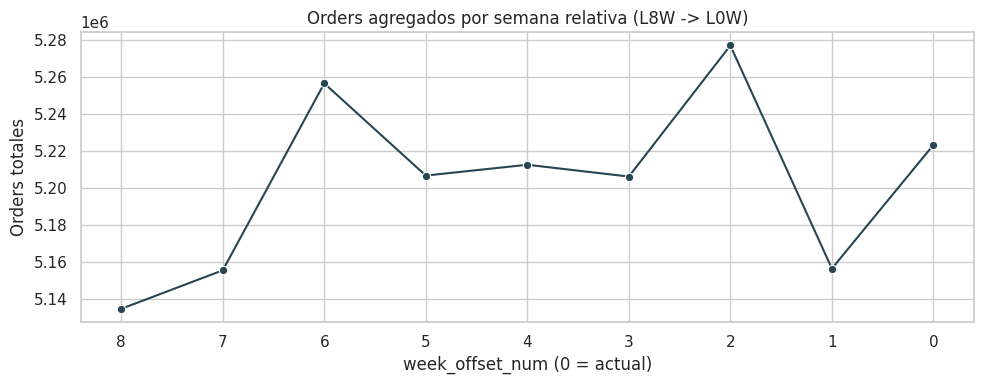

In [18]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=orders_agg, x='week_offset_num', y='VALUE', marker='o', color='#264653')
plt.gca().invert_xaxis()
plt.title('Orders agregados por semana relativa (L8W -> L0W)')
plt.xlabel('week_offset_num (0 = actual)')
plt.ylabel('Orders totales')
plt.tight_layout()
plt.show()

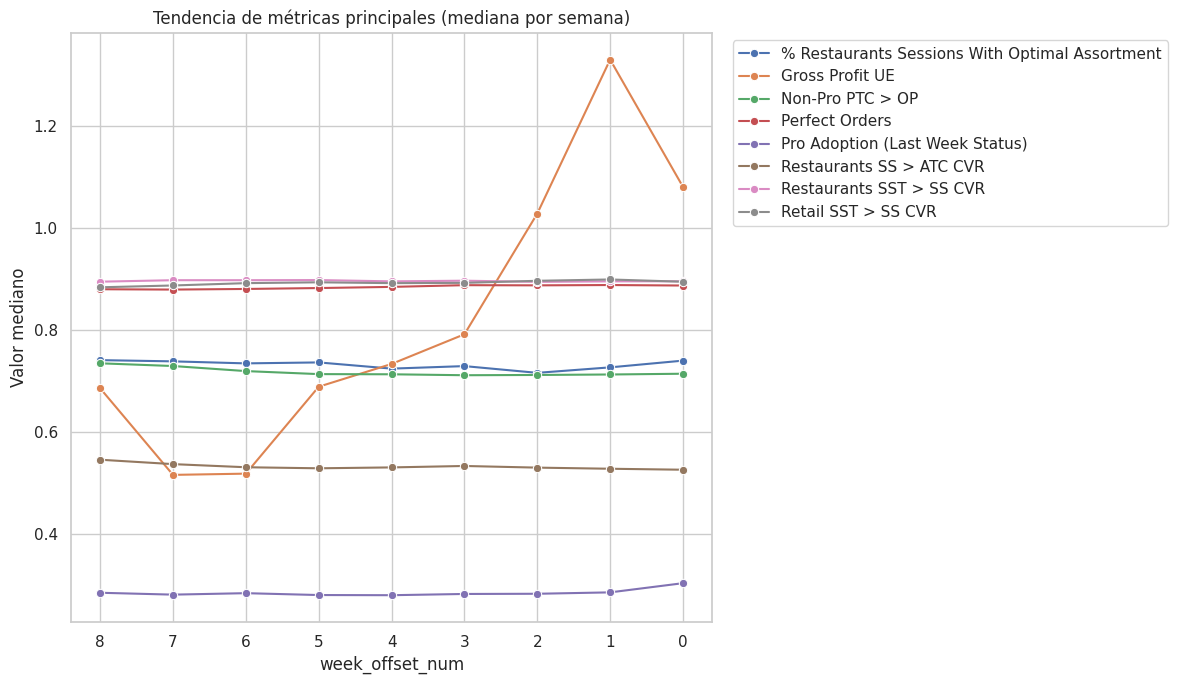

In [19]:
# Métricas principales por volumen
top_metrics = metrics_long['METRIC'].value_counts().head(8).index.tolist()
metric_trend = (
    metrics_long[metrics_long['METRIC'].isin(top_metrics)]
    .groupby(['METRIC','week_offset_num'], dropna=False)['VALUE']
    .median()
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.lineplot(data=metric_trend, x='week_offset_num', y='VALUE', hue='METRIC', marker='o')
plt.gca().invert_xaxis()
plt.title('Tendencia de métricas principales (mediana por semana)')
plt.xlabel('week_offset_num')
plt.ylabel('Valor mediano')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
# Volatilidad por métrica en series por zona
entity_series = metrics_long.groupby(['COUNTRY','CITY','ZONE','METRIC'])['VALUE'].agg(std='std', mean='mean').reset_index()
volatility = entity_series.groupby('METRIC', dropna=False)['std'].median().sort_values(ascending=False).reset_index(name='median_std')
volatility.head(20)

,METRIC,median_std
0,Gross Profit UE,0.607682
1,Turbo Adoption,0.023128
2,% PRO Users Who Breakeven,0.018071
3,Non-Pro PTC > OP,0.016230
4,Restaurants SS > ATC CVR,0.013889
5,Pro Adoption (Last Week Status),0.012760
6,Retail SST > SS CVR,0.010727
7,Perfect Orders,0.010253
8,% Restaurants Sessions With Optimal Assortment,0.007542
9,Restaurants Markdowns / GMV,0.006441


---
**Qué nos llevamos de esta sección**

- Los órdenes totales son estables semana a semana (variaciones WoW menores al 2.5%). No hay caída ni crecimiento sostenido claro a nivel agregado en la ventana de 9 semanas.
- `Gross Profit UE` tiene volatilidad interna (std mediana) significativamente mayor que el resto — las reglas de umbral para esa métrica deben ser más amplias que para otras.
- La volatilidad por métrica varía en órdenes de magnitud: no se puede usar un umbral único de alerta para todas las métricas. El insight engine necesita umbrales calibrados por métrica.
- Con 9 semanas, WoW y rachas de 2–3 semanas son los detectores más confiables. Tendencias de largo plazo no son estadísticamente sólidas con esta ventana.

## 6) Readiness para el motor de insights automáticos

**Qué se hace:** Implementación y prueba de cuatro detectores transparentes que formarán la base del insight engine. Se evalúa la viabilidad de cada detector con los datos actuales.

**Por qué detectores transparentes:**  
Un sistema de insights que usa un modelo de ML como black box no puede explicar por qué disparó una alerta. En un contexto operativo donde las alertas deben justificarse ante el equipo de negocio, los detectores tienen que ser auditables: dada una alerta, debe ser posible reconstruir el cálculo que la generó en 2–3 pasos, mostrar el número concreto y el benchmark contra el que se compara.

**Por qué son defendibles:**  
Cada detector produce un número interpretable por sí mismo: el delta WoW en unidades de la métrica, el conteo de semanas de caída, la diferencia respecto a la mediana del peer, o las desviaciones robustas. No hay "score" opaco — hay un valor con unidad y contexto.

In [21]:
def add_wow_and_streaks(df: pd.DataFrame, id_cols: list[str]) -> pd.DataFrame:
    out = df.sort_values(id_cols + ['week_offset_num'], ascending=[True]*len(id_cols) + [False]).copy()
    out['wow_delta'] = out.groupby(id_cols, dropna=False)['VALUE'].diff(-1)
    out['wow_delta_pct'] = out.groupby(id_cols, dropna=False)['VALUE'].pct_change(-1)
    out['is_decline'] = out['wow_delta'] < 0

    # racha simple de deterioro consecutivo
    out['decline_streak'] = (
        out.groupby(id_cols, dropna=False)['is_decline']
        .transform(lambda s: s.astype(int).groupby((~s).cumsum()).cumsum())
    )
    return out

orders_signal = add_wow_and_streaks(orders_long.copy(), ['COUNTRY','CITY','ZONE','METRIC'])
metrics_signal = add_wow_and_streaks(metrics_long.copy(), ['COUNTRY','CITY','ZONE','METRIC'])

display(orders_signal[['COUNTRY','CITY','ZONE','WEEK_OFFSET','VALUE','wow_delta','wow_delta_pct','decline_streak']].head(12))

,COUNTRY,CITY,ZONE,WEEK_OFFSET,VALUE,wow_delta,wow_delta_pct,decline_streak
453,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L8W,1210.0,66.0,0.057692,0
1695,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L7W,1144.0,-140.0,-0.109034,1
2937,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L6W,1284.0,81.0,0.067332,0
4179,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L5W,1203.0,100.0,0.090662,0
5421,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L4W,1103.0,-66.0,-0.056459,1
6663,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L3W,1169.0,118.0,0.112274,0
7905,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L2W,1051.0,79.0,0.081276,0
9147,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L1W,972.0,-190.0,-0.163511,1
10389,AR,Bahia Blanca,BAHIA_BLANCA_NORTE,L0W,1162.0,NaN,NaN,0
448,AR,Bahia Blanca,BAHIA_BLANCA_SUR,L8W,1248.0,125.0,0.111309,0


In [22]:
# Desviacion vs peer median (detector defendible por benchmark)
metrics_peer = metrics_long.copy()

# Fallback defensivo: si faltaran atributos de segmentacion en metrics_long, traerlos de zone_master.
if ('ZONE_TYPE' not in metrics_peer.columns) or ('ZONE_PRIORITIZATION' not in metrics_peer.columns):
    metrics_peer = metrics_peer.merge(
        zone_master[['COUNTRY', 'CITY', 'ZONE', 'ZONE_TYPE', 'ZONE_PRIORITIZATION']],
        on=['COUNTRY', 'CITY', 'ZONE'],
        how='left'
    )

peer_cols = ['COUNTRY', 'ZONE_TYPE', 'ZONE_PRIORITIZATION', 'METRIC', 'week_offset_num']
peer_median = (
    metrics_peer.groupby(peer_cols, dropna=False)['VALUE']
    .median()
    .reset_index(name='peer_median')
)
metrics_peer = metrics_peer.merge(peer_median, on=peer_cols, how='left')
metrics_peer['vs_peer_abs'] = metrics_peer['VALUE'] - metrics_peer['peer_median']

# z-score robusto por MAD en peer group-week
mad = (
    metrics_peer.groupby(peer_cols, dropna=False)['VALUE']
    .apply(lambda s: np.nanmedian(np.abs(s - np.nanmedian(s))))
    .reset_index(name='peer_mad')
)
metrics_peer = metrics_peer.merge(mad, on=peer_cols, how='left')
metrics_peer['robust_z'] = np.where(
    metrics_peer['peer_mad'] > 0,
    0.6745 * (metrics_peer['VALUE'] - metrics_peer['peer_median']) / metrics_peer['peer_mad'],
    np.nan
)

metrics_peer[['COUNTRY', 'CITY', 'ZONE', 'METRIC', 'week_offset_num', 'VALUE', 'peer_median', 'vs_peer_abs', 'robust_z']].head(15)

,COUNTRY,CITY,ZONE,METRIC,week_offset_num,VALUE,peer_median,vs_peer_abs,robust_z
0,EC,Quito,San Martin de Porras,Retail SST > SS CVR,8,0.602339,0.800493,-0.198154,-1.512650
1,BR,Bauru,FS Parque Jardim Europa/Vila Riachuelo - BAU,Restaurants SST > SS CVR,8,0.857544,0.848065,0.009479,0.134751
2,MX,Mexicali,MXL_Universidad,Retail SST > SS CVR,8,0.900823,0.893257,0.007566,0.545235
3,CL,Santiago De Chile,Colina,Retail SST > SS CVR,8,0.798946,0.800947,-0.002001,-0.045361
4,MX,Guadalajara,Valle Real,Gross Profit UE,8,3.914477,1.415189,2.499288,2.264246
5,MX,Puebla,Angelopolis,Gross Profit UE,8,2.247219,1.415189,0.832030,0.753783
6,BR,Juiz De Fora,MG - JDF - Juiz de Fora,Retail SST > SS CVR,8,0.908167,0.900742,0.007425,0.128485
7,CO,Cartagena,Bocagrande,Retail SST > SS CVR,8,0.931753,0.921235,0.010518,0.565420
8,BR,Campinas,SP - VCP - Jardim Itatinga,Gross Profit UE,8,-4.187063,-2.049671,-2.137392,-0.950828
9,BR,Recife,PE - REC - Zona Norte,Gross Profit UE,8,1.101376,2.476224,-1.374847,-1.168790


In [23]:
readiness_snapshot = pd.DataFrame({
    'detector': ['wow_delta', 'decline_streak', 'vs_peer_abs', 'robust_z'],
    'is_transparent': [True, True, True, True],
    'needs_peer_rules': [False, False, True, True],
    'risk_with_9_weeks': ['medio', 'alto', 'medio', 'alto']
})
readiness_snapshot

,detector,is_transparent,needs_peer_rules,risk_with_9_weeks
0,wow_delta,True,False,medio
1,decline_streak,True,False,alto
2,vs_peer_abs,True,True,medio
3,robust_z,True,True,alto


### Detalle de los detectores implementados

---

**1. WoW Delta (`wow_delta` / `wow_delta_pct`)**  
*Qué detecta:* Cambio de valor entre la semana actual y la semana anterior para una entidad zona+métrica.  
*Por qué es transparente:* Es una resta simple. No hay parámetros ocultos ni entrenamiento.  
*Limitación:* Un único outlier puntual genera un delta alto que no representa tendencia. No distingue ruido de cambio real. Necesita complementarse con rachas o contexto de peer para ser accionable.

---

**2. Decline Streak (`decline_streak`)**  
*Qué detecta:* Número de semanas consecutivas con deterioro (WoW negativo) para una entidad.  
*Por qué es transparente:* Es un contador de signo sobre una secuencia ordenada. Completamente reproducible con los datos visibles.  
*Limitación con 9 semanas:* Una racha de 3–4 semanas consume una fracción relevante de la historia disponible. El detector puede ser muy sensible en métricas con alta volatilidad natural. Umbral recomendado: ≥3 semanas consecutivas para disparar alerta.

---

**3. Desviación vs. Peer Median (`vs_peer_abs`)**  
*Qué detecta:* Cuánto se aleja el valor de una zona de la mediana de su peer group en la misma semana y métrica.  
*Por qué es transparente:* La mediana del peer group es un número concreto que se puede mostrar junto a la alerta ("esta zona está 0.05 por debajo de la mediana de su peer de 45 zonas").  
*Limitación:* La calidad del detector depende directamente del tamaño del peer group. Grupos con <10 zonas generan medianas frágiles — ver sección 4.

---

**4. Robust Z-Score con MAD (`robust_z`)**  
*Qué detecta:* Cuántas "desviaciones robustas" se aleja una zona del centro del peer group. Valor > |2.5| se considera anómalo.  
*Cálculo:* `robust_z = 0.6745 × (valor − mediana_peer) / MAD_peer`, donde MAD es la mediana de las desviaciones absolutas respecto a la mediana del peer.  
*Por qué robusto:* A diferencia del z-score estándar (que usa media y STD), este no se infla por outliers del peer group. El factor 0.6745 lo hace comparable en escala a un z-score estándar para distribuciones normales.  
*Limitación:* Si MAD = 0 (peer muy homogéneo), el cálculo no está definido — se asigna NaN. Requiere manejo explícito de este edge case en producción.

---
**Qué nos llevamos de esta sección**

- Los 4 detectores son implementables con datos actuales y son auditables: ninguno requiere entrenamiento ni parámetros opacos.
- `wow_delta` y `vs_peer_abs` tienen riesgo medio con 9 semanas — útiles en producción con thresholds calibrados por métrica.
- `decline_streak` y `robust_z` tienen riesgo alto — requieren umbrales más estrictos y manejo de edge cases (MAD=0, peer pequeño) antes de activar en producción.
- No se recomienda activar ningún detector sin un umbral explícito por métrica validado con el equipo de negocio.

## 7) Exploración de hipótesis explicativas (no causalidad)

**Qué se hace:** Exploración de co-movimientos entre cambios WoW de métricas operativas y cambios WoW de órdenes. El objetivo es generar hipótesis de trabajo para priorizar investigación, no establecer relaciones causales.

**Por qué Spearman y no Pearson:**  
Spearman calcula correlación sobre los *rangos* de los valores, no sobre los valores directos. Esto lo hace robusto frente a outliers extremos (como los de `Lead Penetration` o `Gross Profit UE`) y no requiere asumir distribución normal. Con variables operativas de naturaleza heterogénea, Spearman es la elección metodológicamente más segura.

**Cómo leer el coeficiente:**  
Un valor como `0.229` (observado para `Restaurants SS > ATC CVR`) significa: cuando esta métrica tiene un cambio semanal mayor de lo habitual, las órdenes también tienden a tener un cambio semanal mayor de lo habitual, con una asociación de rango de 0.229. No es un efecto grande — pero es estadísticamente significativo dado el volumen de observaciones (n ≈ 7,500). En lenguaje simple: hay una asociación débil pero consistente.

**Por qué no es causalidad:**  
Correlación entre WoW de dos variables puede surgir de: (1) A causa B, (2) B causa A, (3) una tercera variable C causa ambas, o (4) coincidencia estadística en muestra corta. Con 9 semanas y datos observacionales no hay forma de discriminar entre estas opciones.

**Cómo se usa correctamente:**
- **Exploración:** identificar qué métricas merecen análisis adicional.
- **Priorización:** las correlaciones más altas son candidatas prioritarias para experimentos controlados.
- **Hipótesis:** "mejorar CVR de restaurantes podría estar asociado con más órdenes — vale la pena un A/B test".
- **No usar para:** decisiones operativas directas, scoring automático, ni narrativa de causalidad en el bot.

In [24]:
# Construcción de dataset de co-movimientos WoW
orders_wow = orders_signal[['COUNTRY','CITY','ZONE','week_offset_num','wow_delta_pct']].rename(columns={'wow_delta_pct':'orders_wow_pct'})
metrics_wow = metrics_signal[['COUNTRY','CITY','ZONE','METRIC','week_offset_num','wow_delta_pct']].rename(columns={'wow_delta_pct':'metric_wow_pct'})

comov = metrics_wow.merge(orders_wow, on=['COUNTRY','CITY','ZONE','week_offset_num'], how='inner')
comov = comov.replace([np.inf, -np.inf], np.nan).dropna(subset=['orders_wow_pct','metric_wow_pct'])

corrs = []
for metric, g in comov.groupby('METRIC', dropna=False):
    if len(g) < 30:
        continue
    corr, p = spearmanr(g['orders_wow_pct'], g['metric_wow_pct'], nan_policy='omit')
    corrs.append((metric, len(g), corr, p))

corr_df = pd.DataFrame(corrs, columns=['METRIC','n_obs','spearman_corr','p_value']).sort_values('spearman_corr', ascending=False)
corr_df.head(20)

,METRIC,n_obs,spearman_corr,p_value
9,Restaurants SS > ATC CVR,7498,0.229090,7.133232e-90
5,Non-Pro PTC > OP,7511,0.168435,6.416717e-49
10,Restaurants SST > SS CVR,7498,0.125416,1.137942e-27
12,Turbo Adoption,2101,0.087322,6.127861e-05
1,% Restaurants Sessions With Optimal Assortment,5967,0.082338,1.892510e-10
11,Retail SST > SS CVR,7438,0.071619,6.266313e-10
8,Restaurants Markdowns / GMV,7011,0.063006,1.292526e-07
0,% PRO Users Who Breakeven,6992,0.040812,6.414629e-04
6,Perfect Orders,7300,0.030003,1.035859e-02
3,Lead Penetration,7252,0.015953,1.743359e-01


In [25]:
# Zonas de mayor crecimiento reciente (L1W -> L0W) y contraste con peers
orders_recent = orders_long[orders_long['WEEK_OFFSET'].isin(['L1W', 'L0W'])].copy()
orders_pivot = orders_recent.pivot_table(index=['COUNTRY','CITY','ZONE'], columns='WEEK_OFFSET', values='VALUE', aggfunc='sum').reset_index()
orders_pivot['orders_growth_abs_l0_vs_l1'] = orders_pivot['L0W'] - orders_pivot['L1W']

top_growth_zones = orders_pivot.sort_values('orders_growth_abs_l0_vs_l1', ascending=False).head(20)
top_growth_zones.head(20)

WEEK_OFFSET,COUNTRY,CITY,ZONE,L0W,L1W,orders_growth_abs_l0_vs_l1
9,AR,Buenos Aires,CABALLITO,77294.0,74859.0,2435.0
569,CL,Santiago De Chile,Ñuñoa Providencia,27846.0,25644.0,2202.0
557,CL,Santiago De Chile,Santiago_centro,15549.0,13566.0,1983.0
25,AR,Buenos Aires,Microcentro,97709.0,95960.0,1749.0
565,CL,Santiago De Chile,las_condes_vitacura,28605.0,26942.0,1663.0
1209,PE,Lima,San isidro,114141.0,112622.0,1519.0
907,MX,Guadalajara,La estancia,61356.0,59945.0,1411.0
1208,PE,Lima,San Miguel,37478.0,36107.0,1371.0
861,MX,Ciudad De Mexico,Roma-Polanco,85190.0,83850.0,1340.0
1196,PE,Lima,Miraflores,124757.0,123431.0,1326.0


**Separación metodológica explícita:**

| Nivel | Qué dice este análisis |
|---|---|
| **Observación** | `Restaurants SS > ATC CVR` tiene correlación Spearman de +0.229 con el cambio WoW de órdenes (p < 0.001, n ≈ 7,500). |
| **Asociación** | Semanas con mayor mejora en este CVR tienden a coincidir con semanas de mayor crecimiento de órdenes, a nivel zona-semana. |
| **Hipótesis** | Mejorar la tasa de conversión de sesión a carrito en restaurantes podría contribuir al crecimiento de órdenes en una zona. |
| **Límite** | Esta hipótesis no está confirmada. La correlación es débil (0.229), la ventana es corta (9 semanas), y variables confundidoras no están controladas. Requiere experimentación para validar. |

Las correlaciones negativas (como `Gross Profit UE` con −0.042) no indican que mayor rentabilidad cause menos órdenes — son asociaciones marginales que no deben interpretarse como dirección de efecto.

---
**Qué nos llevamos de esta sección**

- La métrica con mayor co-movimiento con órdenes es `Restaurants SS > ATC CVR` (ρ=0.229) — candidata más prioritaria para hipótesis de mejora operativa.
- Ninguna correlación supera 0.25 — las asociaciones son débiles. No hay un "driver dominante" evidente en los datos actuales.
- Spearman fue la elección correcta: los outliers de `Lead Penetration` y `Gross Profit UE` no distorsionaron los resultados.
- El valor de este análisis es priorización de hipótesis, no confirmación de mecanismos causales.

## 8) Matriz de soporte para preguntas del futuro bot

**Qué se hace:** Mapeo de los tipos de pregunta que el brief del sistema anticipa, contra los datos y transformaciones disponibles hoy.

**Qué significan los niveles de soporte:**

- **"bien":** Los datos existen, el grano es correcto y la transformación es directa. No requiere decisiones de negocio adicionales para ejecutarse. El bot puede responder esta pregunta con lógica determinística hoy.
- **"parcial":** Los datos existen pero la respuesta requiere decisiones no resueltas: definir umbrales, elegir tratamiento para zonas sin match, o resolver la dirección deseable de una métrica. Se puede implementar una versión con advertencias, pero no una versión lista para producción.
- **"mal"** *(no aparece en la tabla actual):* Los datos no existen, el grano es insuficiente, o la pregunta requiere información externa no disponible en este dataset.

**Por qué algunas preguntas del brief están listas y otras no:**  
Las preguntas de consulta directa (ranking, tendencia, agregación) dependen solo de la estructura de datos — y esa estructura está validada. Las preguntas de diagnóstico o hipótesis (¿por qué creció esta zona?, ¿qué zonas tienen un problema?) requieren semántica de métricas y umbrales de negocio que aún no están definidos formalmente. El cuello de botella actual es semántico, no técnico.

In [26]:
bot_support = pd.DataFrame([
    {
        'question_example': 'Top 5 por métrica esta semana',
        'question_type': 'ranking_snapshot',
        'datasets': 'metrics_long',
        'transformations': 'filtrar L0W, ordenar VALUE por METRIC y dimensión',
        'support_level': 'bien',
        'risks': 'dirección deseable de métrica no siempre clara',
        'future_module': 'semantic_query_engine'
    },
    {
        'question_example': 'Comparación wealthy vs non wealthy',
        'question_type': 'segment_comparison',
        'datasets': 'metrics_long + zone_master',
        'transformations': 'join con ZONE_TYPE, agregación y normalización',
        'support_level': 'bien',
        'risks': 'peer groups desbalanceados por país',
        'future_module': 'peer_benchmark_engine'
    },
    {
        'question_example': 'Tendencia de Gross Profit UE',
        'question_type': 'trend',
        'datasets': 'metrics_long',
        'transformations': 'serie temporal por offset, WoW y suavizado simple',
        'support_level': 'bien',
        'risks': 'historia corta (9 semanas)',
        'future_module': 'trend_engine'
    },
    {
        'question_example': 'Promedio por país',
        'question_type': 'aggregation',
        'datasets': 'metrics_long / orders_long',
        'transformations': 'groupby COUNTRY, control de nulos y cobertura',
        'support_level': 'bien',
        'risks': 'mezcla de zonas con historia incompleta',
        'future_module': 'semantic_query_engine'
    },
    {
        'question_example': 'Zonas con alto Lead Penetration y bajo Perfect Orders',
        'question_type': 'multi_metric_screening',
        'datasets': 'metrics_long',
        'transformations': 'pivot por METRIC en L0W, reglas de umbral',
        'support_level': 'parcial',
        'risks': 'umbrales requieren definición de negocio',
        'future_module': 'rule_based_insight_engine'
    },
    {
        'question_example': 'Zonas que más crecen en orders y posibles explicaciones',
        'question_type': 'growth_hypothesis',
        'datasets': 'orders_long + metrics_long + zone_master',
        'transformations': 'growth ranking + co-movimientos + comparación peer',
        'support_level': 'parcial',
        'risks': 'hipótesis no causal, muestra temporal corta',
        'future_module': 'hypothesis_generator'
    }
])
bot_support

,question_example,question_type,datasets,transformations,support_level,risks,future_module
0,Top 5 por métrica esta semana,ranking_snapshot,metrics_long,"filtrar L0W, ordenar VALUE por METRIC y dimensión",bien,dirección deseable de métrica no siempre clara,semantic_query_engine
1,Comparación wealthy vs non wealthy,segment_comparison,metrics_long + zone_master,"join con ZONE_TYPE, agregación y normalización",bien,peer groups desbalanceados por país,peer_benchmark_engine
2,Tendencia de Gross Profit UE,trend,metrics_long,"serie temporal por offset, WoW y suavizado simple",bien,historia corta (9 semanas),trend_engine
3,Promedio por país,aggregation,metrics_long / orders_long,"groupby COUNTRY, control de nulos y cobertura",bien,mezcla de zonas con historia incompleta,semantic_query_engine
4,Zonas con alto Lead Penetration y bajo Perfect...,multi_metric_screening,metrics_long,"pivot por METRIC en L0W, reglas de umbral",parcial,umbrales requieren definición de negocio,rule_based_insight_engine
5,Zonas que más crecen en orders y posibles expl...,growth_hypothesis,orders_long + metrics_long + zone_master,growth ranking + co-movimientos + comparación ...,parcial,"hipótesis no causal, muestra temporal corta",hypothesis_generator


---
**Qué nos llevamos de esta sección**

- 4 de 6 tipos de pregunta tienen soporte "bien" — los casos básicos del bot están cubiertos con los datos actuales.
- Las preguntas de diagnóstico multi-métrica y de hipótesis explicativas son "parcial" — generan más valor pero requieren más trabajo de definición semántica.
- El cuello de botella no es técnico sino semántico: falta el catálogo de métricas con dirección deseable y umbrales de negocio.
- La arquitectura de funciones determinísticas (no SQL libre via LLM) está justificada por este análisis.

## 9) Hallazgos metodológicos del EDA

Hallazgos orientados a diseño analítico (no reporte ejecutivo final de negocio).

In [27]:
method_findings = [
    'La base long es consistente en grano y permite consultas determinísticas por WEEK_OFFSET.',
    'El mismatch de cobertura entre métricas y órdenes es real y debe modelarse explícitamente.',
    'Comparaciones defendibles requieren peer groups mínimos; grupos pequeños son frágiles para benchmark.',
    'Detectores transparentes (WoW, rachas, desviación vs peer median, robust_z) son viables con cautela.',
    'La semántica de orientación de métricas no está cerrada; se requiere catálogo formal antes de automatizar narrativa.',
    'Con 9 semanas, la estabilidad temporal es limitada para afirmar patrones persistentes complejos.'
]
for i, f in enumerate(method_findings, start=1):
    print(f'{i}. {f}')

1. La base long es consistente en grano y permite consultas determinísticas por WEEK_OFFSET.
2. El mismatch de cobertura entre métricas y órdenes es real y debe modelarse explícitamente.
3. Comparaciones defendibles requieren peer groups mínimos; grupos pequeños son frágiles para benchmark.
4. Detectores transparentes (WoW, rachas, desviación vs peer median, robust_z) son viables con cautela.
5. La semántica de orientación de métricas no está cerrada; se requiere catálogo formal antes de automatizar narrativa.
6. Con 9 semanas, la estabilidad temporal es limitada para afirmar patrones persistentes complejos.


## 10) Próximos pasos recomendados

Recomendaciones concretas para pasar de EDA a arquitectura funcional del sistema analítico.

In [28]:
next_steps = pd.DataFrame([
    {'layer': 'capa_semantica', 'recommendation': 'Definir contrato de métricas, dimensiones, agregaciones válidas y ventanas.'},
    {'layer': 'metric_catalog', 'recommendation': 'Formalizar unidad, orientación deseable y riesgos de interpretación por métrica.'},
    {'layer': 'peer_group_rules', 'recommendation': 'Versionar reglas de peers y mínimo de tamaño para benchmark confiable.'},
    {'layer': 'insight_detectors', 'recommendation': 'Implementar detectores transparentes con thresholds auditables por métrica.'},
    {'layer': 'bot_functions', 'recommendation': 'Mapear tipos de pregunta a funciones determinísticas y no a SQL libre por LLM.'},
    {'layer': 'not_do_yet', 'recommendation': 'No afirmar causalidad ni desplegar scoring final con historia de solo 9 semanas.'}
])
next_steps

,layer,recommendation
0,capa_semantica,"Definir contrato de métricas, dimensiones, agr..."
1,metric_catalog,"Formalizar unidad, orientación deseable y ries..."
2,peer_group_rules,Versionar reglas de peers y mínimo de tamaño p...
3,insight_detectors,Implementar detectores transparentes con thres...
4,bot_functions,Mapear tipos de pregunta a funciones determiní...
5,not_do_yet,No afirmar causalidad ni desplegar scoring fin...


### Cierre

Este EDA prioriza trazabilidad, comparabilidad y defendibilidad para preparar la capa semántica y el insight engine.

No se construye chatbot ni sistema final en este notebook.